# ENCM 369 — Lab 2
Name: Rajdeep Das
UCID: 30186009

# Question 1 — Control Flow Simulation in Python

## (a) Simulate a JUMP that skips three instructions

The instruction at address `1` jumps to address `5`, skipping addresses `2`, `3`, and `4`.


In [ ]:
program = [
    "LOAD",
    "JUMP 5",
    "INSTRUCTION_A",
    "INSTRUCTION_B",
    "INSTRUCTION_C",
    "ADD",
    "HALT"
]

pc = 0

while pc < len(program):
    instr = program[pc]
    print(f"PC = {pc}: {instr}")

    if instr.startswith("JUMP"):
        target = int(instr.split()[1])
        print(f"Jumping to address {target}")
        pc = target

    elif instr == "HALT":
        print("Execution stopped.")
        break

    else:
        pc += 1


PC = 0: LOAD
PC = 1: JUMP 5
Jumping to address 5
PC = 5: ADD
PC = 6: HALT
Execution stopped.


## (b) Simulate CALL to address 20 and RETURN




In [ ]:
program = {
    0: "LOAD",
    1: "CALL 20",
    2: "SUB",
    3: "HALT",
    20: "ADD",
    21: "RETURN"
}

pc = 0
stack = []

while pc < len(program):
    instr = program[pc]
    print(f"PC = {pc}: {instr}")

    if instr.startswith("CALL"):
        target = int(instr.split()[1])

        print(f"Stack before CALL: {stack}")
        stack.append(pc + 1)
        print(f"Stack after CALL:  {stack}")

        pc = target

    elif instr == "RETURN":
        if stack:
            print(f"Stack before RETURN: {stack}")
            pc = stack.pop()
            print(f"Stack after RETURN:  {stack}")
        else:
            print("Error: stack is empty.")
            break

    elif instr == "HALT":
        print("Execution stopped.")
        break

    else:
        print(f"Executing: {instr}")
        pc += 1


PC = 0: LOAD
Executing: LOAD
PC = 1: CALL 20
Stack before CALL: []
Stack after CALL:  [2]


## (c) BRANCH when `R1 == 0`

In [ ]:
registers = {"R1": 0}
pc = 0

instruction = "BRANCH R1 == 0, 50"

parts = instruction.split()
reg = parts[1]
value = int(parts[3].strip(","))
target = int(parts[4])

print(f"Current PC = {pc}")

if registers[reg] == value:
    print(f"Condition true: {reg} == {value}")
    pc = target
else:
    print(f"Condition false: {reg} != {value}")
    pc += 1

print(f"New PC = {pc}")


Current PC = 0
Condition true: R1 == 0
New PC = 50


## (d) BRANCH when `R1 > 10`

In [ ]:
def simulate_branch(r1_value):
    registers = {"R1": r1_value}
    pc = 0

    instruction = "BRANCH R1 > 10, 50"

    parts = instruction.split()
    reg = parts[1]
    value = int(parts[3].strip(","))
    target = int(parts[4])

    print(f"R1 = {registers[reg]}")
    print(f"PC before BRANCH = {pc}")

    if registers[reg] > value:
        print("Condition true: branch taken.")
        pc = target
    else:
        print("Condition false: branch not taken.")
        pc += 1

    print(f"PC after BRANCH = {pc}")


print("Test 1: True case")
simulate_branch(15)

print("\nTest 2: False case")
simulate_branch(7)


Test 1: True case
R1 = 15
PC before BRANCH = 0
Condition true: branch taken.
PC after BRANCH = 50

Test 2: False case
R1 = 7
PC before BRANCH = 0
Condition false: branch not taken.
PC after BRANCH = 1


# Question 2 — Designing Custom I/O Instructions

## (a) Define two new instructions

### `GET R1`
Reads an integer from the user or input device and stores it in register `R1`.

### `DISPLAY R1`
Sends the value stored in register `R1` to an output device such as the screen.


## (b)–(c) Simulate GET and DISPLAY

In [ ]:
registers = {
    "R1": 0
}

program = [
    "GET R1",
    "DISPLAY R1",
    "HALT"
]

pc = 0

while pc < len(program):
    instr = program[pc]

    if instr.startswith("GET"):
        reg = instr.split()[1]

        value = int(input(f"Enter a value for {reg}: "))
        registers[reg] = value

        print(f"GET → {reg} = {registers[reg]}")
        pc += 1

    elif instr.startswith("DISPLAY"):
        reg = instr.split()[1]

        print(f"DISPLAY → {registers[reg]}")
        pc += 1

    elif instr == "HALT":
        print("Executing: HALT")
        break

    else:
        print(f"Unknown instruction: {instr}")
        pc += 1


## (d) Difference from READ and WRITE

`GET` and `DISPLAY` communicate directly with a user or device:

- `GET` receives immediate input from a keyboard or device.
- `DISPLAY` immediately sends a value to a screen or output device.

Traditional file operations use stored data:

- `READ R1, data.txt` loads file contents into `R1`.
- `WRITE R1, output.txt` saves the contents of `R1` to a file.

Files provide persistent storage, while direct input/output normally handles immediate communication.


# Question 3 — Combining I/O and Control Flow

## (a)–(c) Complete simulation

The program handles three cases:

- Negative input: jumps to `HALT`.
- Positive input: calls a subroutine that computes the square.
- Zero input: branches to a routine that prints `Zero detected!` before halting.


In [ ]:
registers = {
    "R1": 0,
    "R2": 0,
    "R3": "Zero detected!"
}

stack = []

program = [
    "IN R1",                 # Address 0
    "BRANCH R1 == 0, 7",     # Address 1: zero case
    "BRANCH R1 < 0, 5",      # Address 2: negative case
    "CALL 9",                # Address 3: call square subroutine
    "OUT R2",                # Address 4: display square
    "JUMP 6",                # Address 5: jump to HALT
    "HALT",                  # Address 6
    "OUT R3",                # Address 7: print zero message
    "JUMP 6",                # Address 8: jump to HALT
    "MUL R2, R1, R1",        # Address 9: R2 = R1 × R1
    "RETURN"                 # Address 10
]

pc = 0

while pc < len(program):
    instr = program[pc]
    print(f"PC = {pc}: {instr}")

    if instr.startswith("IN"):
        reg = instr.split()[1]
        registers[reg] = int(input("Enter a number: "))
        print(f"IN → {reg} = {registers[reg]}")
        pc += 1

    elif instr.startswith("BRANCH"):
        parts = instr.replace(",", "").split()

        reg = parts[1]
        operator = parts[2]
        value = int(parts[3])
        target = int(parts[4])

        if operator == "==":
            condition = registers[reg] == value
        elif operator == "<":
            condition = registers[reg] < value
        else:
            condition = False

        if condition:
            print(f"Branch taken → address {target}")
            pc = target
        else:
            print("Branch not taken")
            pc += 1

    elif instr.startswith("CALL"):
        target = int(instr.split()[1])

        stack.append(pc + 1)
        print(f"Stack after CALL: {stack}")

        pc = target

    elif instr == "RETURN":
        pc = stack.pop()

        print(f"RETURN → address {pc}")
        print(f"Stack after RETURN: {stack}")

    elif instr.startswith("MUL"):
        parts = instr.replace(",", "").split()

        destination = parts[1]
        source1 = parts[2]
        source2 = parts[3]

        registers[destination] = (
            registers[source1] * registers[source2]
        )

        print(f"MUL → {destination} = {registers[destination]}")
        pc += 1

    elif instr.startswith("OUT"):
        reg = instr.split()[1]

        print(f"OUT → {registers[reg]}")
        pc += 1

    elif instr.startswith("JUMP"):
        target = int(instr.split()[1])

        print(f"JUMP → address {target}")
        pc = target

    elif instr == "HALT":
        print("Executing: HALT")
        break

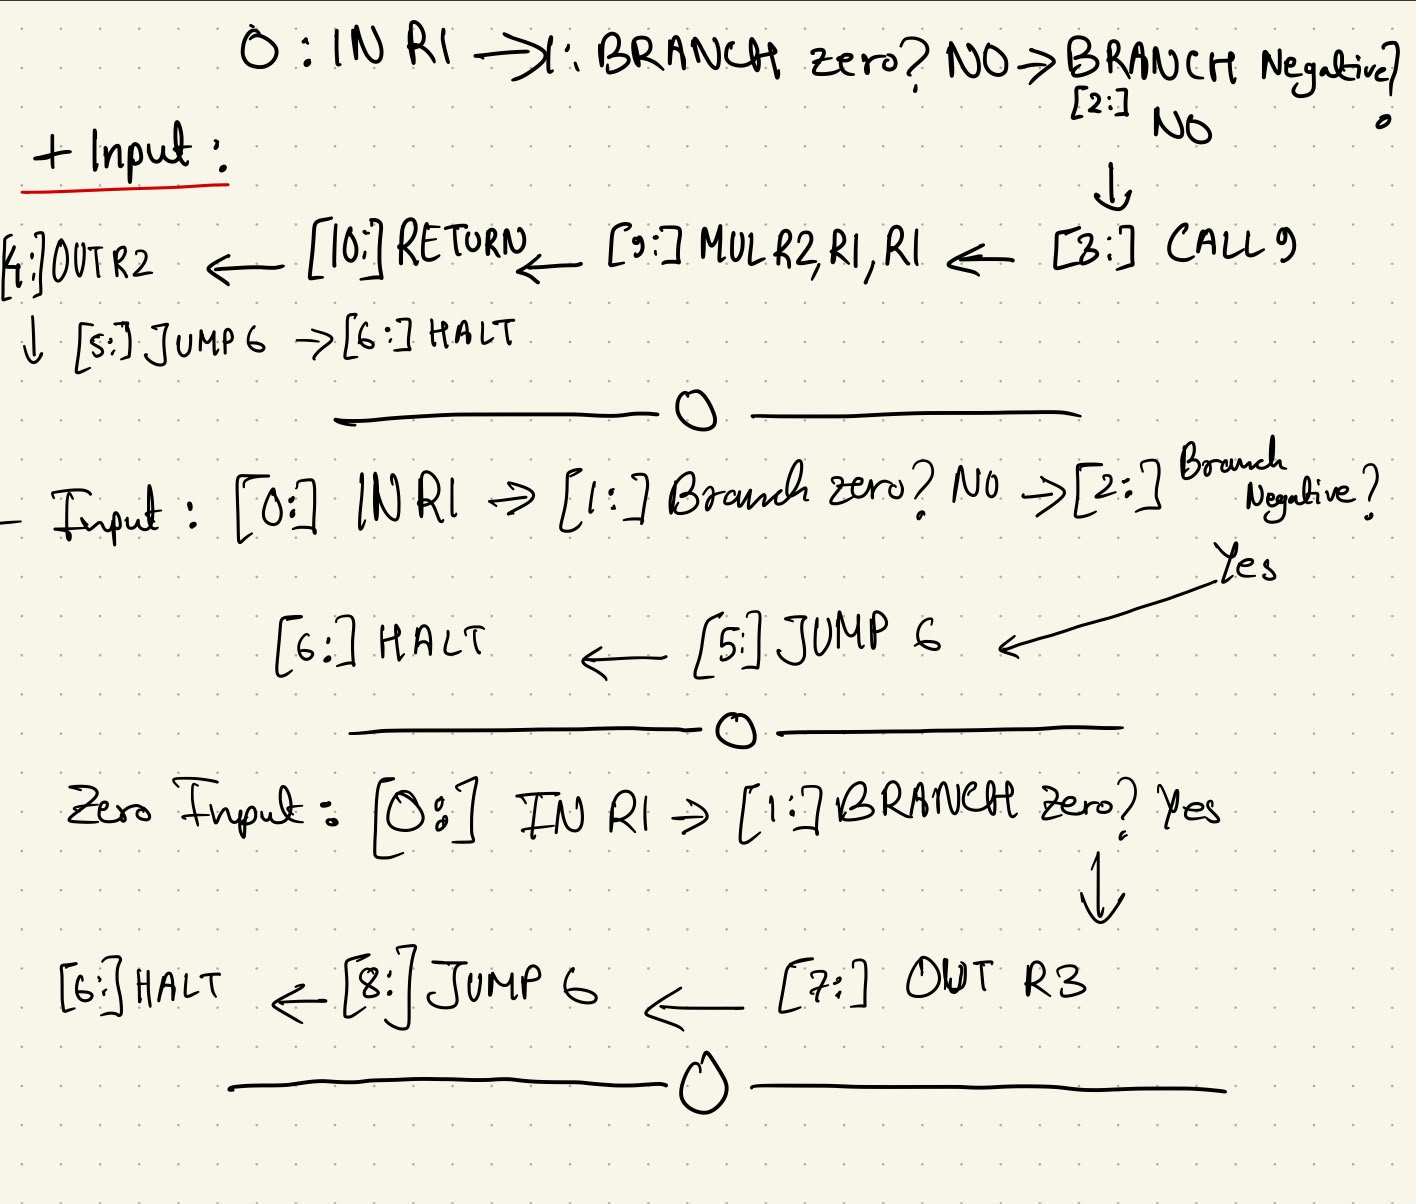

# Question 4 — Cython for Computer Organization Simulations

## (a) Python implementation

In [6]:
def sum_python(n):
    total = 0

    for i in range(1, n + 1):
        total += i

    return total


n = int(input("Enter n: "))
result = sum_python(n)

print("Python result:", result)


Enter n: 6
Python result: 21


For `n = 1,000,000`, the result is `500000500000`.

## (b) Cython implementation

Run the next two cells in Google Colab or in a Jupyter environment with Cython installed.


In [1]:
!pip install cython
%load_ext cython


In [4]:
%%cython

cpdef long long sum_cython(long long n):
    cdef long long total = 0
    cdef long long i

    for i in range(1, n + 1):
        total += i

    return total


`long long` is used because `500000500000` is larger than the maximum value of a 32-bit integer.

## (c) Measure Python and Cython execution time

In [7]:
import time

n = 1_000_000

# Python execution time
start = time.time()
python_result = sum_python(n)
end = time.time()

print("Python result:", python_result)
print("Python execution time:", end - start, "seconds")


# Cython execution time
start = time.time()
cython_result = sum_cython(n)
end = time.time()

print("Cython result:", cython_result)
print("Cython execution time:", end - start, "seconds")

Python result: 500000500000
Python execution time: 0.06031060218811035 seconds
Cython result: 500000500000
Cython execution time: 0.0004620552062988281 seconds


## (d) Two benefits of Cython for future hardware simulations

### 1. Faster simulation loops

Hardware simulations may execute thousands or millions of instruction cycles. Typed Cython loops can simulate program counters, ALU operations, registers and clock cycles faster than ordinary Python loops.

### 2. Efficient low-level operations

Cython supports C-level integer types and efficient bitwise operations. This is useful for modelling fixed-size registers, binary arithmetic, masks, shifts and other low-level CPU operations.
